In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import norm
import jax.numpy as jnp
import jax
from jax.scipy.special import logsumexp

from experiments.pcr.pcr_antithetic_cv_selector import PCRAntitheticCVSelection
from flows.train import train_with_validation
from utils.utils import ci_bisection

In [2]:
data_path = "experiments/single_cell/"
df = pd.read_csv(os.path.join(data_path, "filtered_gene_expression.csv"), index_col=0)
cell_types = pd.read_csv(os.path.join(data_path, "cell_types.csv"), index_col=0)
cell_types = cell_types.loc[df.index]
df['type'] = cell_types['fine_cell_type']
df = df.loc[df['type'].isin(['memory B cell', 'naive B cell'])]

X = np.array(df.iloc[:, :-1])
y = np.array(df['type'] == 'memory B cell')
print(X.shape, round(y.mean(), 2))

(233, 2000) 0.6


In [3]:
X_PC = np.linalg.svd(X, full_matrices=False)[0][:, :10] * np.sqrt(len(y))
df_pc = pd.DataFrame(X_PC, columns=['PC' + str(i) for i in range(1, 11)])
df_pc['y'] = list(df['type'])

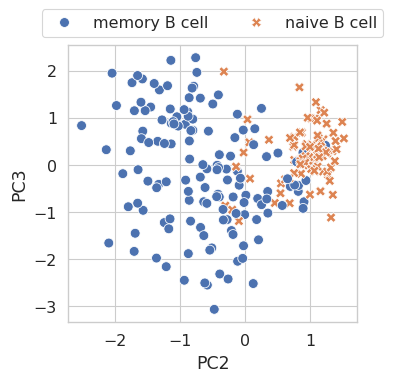

In [4]:
plt.figure(figsize=(4, 4))
sns.set_theme(context='paper', style='whitegrid', font_scale=1.3)
sns.scatterplot(data=df_pc, x='PC2', y='PC3', hue='y', style='y', s=50)
plt.legend(title='', loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2)
plt.tight_layout()

In [5]:
selector = PCRAntitheticCVSelection(X_PC, y, alpha_cv=0.1, K_cv=10)
d = selector.d
d

3

In [6]:
sig_level = 0.05
cis_naive, pvalues_naive, _ = selector.naive_inference(sig_level=sig_level)
pvalues_naive, cis_naive

(array([5.43018965e-06, 8.89603804e-16, 4.64507220e-03]),
 array([[-2.02788756, -0.80632965],
        [-4.24941748, -2.58387089],
        [-1.59713115, -0.29028116]]))

In [7]:
n_train = 2000
n_val = 500
rng = np.random.default_rng(0)
train_samples, train_contexts = selector.generate_training_data(rng, n_train+n_val)
print(train_samples.shape)

100%|██████████| 2500/2500 [05:05<00:00,  8.18it/s]


(2478, 3)


In [8]:
mean_shift = np.mean(train_samples, axis=0)
cov_chol = np.linalg.cholesky(np.linalg.inv(np.atleast_2d(np.cov(train_samples.T))))
samples_center = (train_samples - mean_shift) @ cov_chol

val_samples = samples_center[n_train:]
val_contexts = train_contexts[n_train:]
train_samples = samples_center[:n_train]
train_contexts = train_contexts[:n_train]

suff_stat = selector.score[:d]
sd_suff_stat = np.sqrt(np.diag(selector.H_hat))
beta_hat = selector.beta_hat
sd_beta = np.sqrt(np.diag(selector.Sigma))

In [9]:
model, params, val_losses = train_with_validation(train_samples, train_contexts, val_samples, val_contexts, learning_rate=1e-4, max_iter=10000, checkpoint_every=1000, hidden_dims=[8], n_layers=12, num_bins=20, seed=2)
val_losses = np.array(val_losses)

Iteration:  1000 Validation loss:  3.4350626
Iteration:  2000 Validation loss:  3.0514283
Iteration:  3000 Validation loss:  3.009749
Iteration:  4000 Validation loss:  2.9822254
Iteration:  5000 Validation loss:  2.9696505
Iteration:  6000 Validation loss:  2.973655
Iteration:  7000 Validation loss:  2.9869704
Iteration:  8000 Validation loss:  3.002251
Iteration:  9000 Validation loss:  3.0118978
Iteration:  10000 Validation loss:  3.0225284


In [10]:
suff_stat_center = cov_chol.T @ (suff_stat - mean_shift)
z_value = model.apply(params, suff_stat_center, context=np.zeros(d), method=model.inverse)[0]
Z = model.apply(params, val_samples, val_contexts, method=model.inverse)[0]

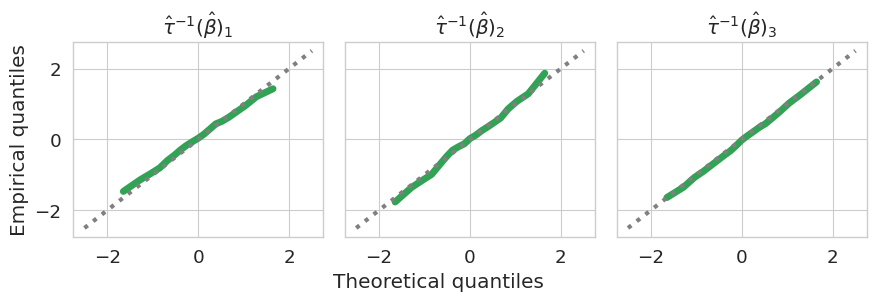

In [11]:
xx = np.linspace(-2.5, 2.5, 100)
sns.set_theme(context='paper', style='whitegrid', font_scale=1.5)
fig, ax = plt.subplots(1, d, figsize=(9, 3), sharey=True, sharex=True)
ps = np.linspace(0.05, 0.95, 19)
quantiles = norm.ppf(ps)
for j in range(d):
    q = np.quantile(Z[:, j], ps)
    ax[j].plot(quantiles, q, ls='-', lw=5, color='#31a354', label='Empirical quantiles')
    ax[j].plot(xx, xx, ls=':', lw=3, c='grey', label='Theoretical quantiles')
    ax[j].set_title(rf'$\hat\tau^{{{-1}}}(\hat\beta)_{{{j+1}}}$')
ax[0].set_xticks([-2, 0, 2])
ax[0].set_yticks([-2, 0, 2])
ax[0].set_ylabel('Empirical quantiles')
fig.text(0.5, 0.0, 'Theoretical quantiles', ha='center')
plt.tight_layout()
plt.savefig('experiments/single_cell/pbmc_qq_antithetic.pdf', bbox_inches='tight')

In [12]:
def neg_loglik(suff_stat, beta_null):
    suff_stat_center_ = cov_chol.T @ (suff_stat - mean_shift)
    return model.apply(params, suff_stat_center_, beta_null, method=model.forward_kl)

pvalues_adjusted = np.zeros(d)
cis_adjusted = np.zeros((d, 2))

for j in range(d):
    c = np.eye(d)[j]
    beta_perp = suff_stat - c * suff_stat[j]
    gridsize = 200
    grid = jnp.linspace(-5, 5, gridsize) * sd_suff_stat[j] + suff_stat[j]

    @jax.jit
    def logp_j(beta_hat_j, beta_null_j):
        beta_ = jnp.zeros(d)
        beta_ = beta_.at[j].set(beta_null_j)
        return -neg_loglik(beta_perp + c * beta_hat_j, beta_)

    @jax.jit
    def get_pvalue(beta_null_j):
        logp = jax.vmap(logp_j, in_axes=(0, None))(grid, beta_null_j)
        isnan = jnp.all(jnp.isnan(logp))
        logp = jnp.nan_to_num(logp, nan=-np.inf)
        logp -= logp.max()
        log_normalization_const = logsumexp(logp)

        idx_left = (grid <= suff_stat[j]) 
        log_numerator_left = logsumexp(jnp.where(idx_left, logp, -jnp.inf))
        pval = jnp.exp(log_numerator_left - log_normalization_const)
        pval = jax.lax.select(pval < 0.5, 2 * pval, 2 * (1 - pval))
        return jax.lax.select(isnan, 0., pval)

    pvalues_adjusted[j] = get_pvalue(0.)
    cis_adjusted[j] = ci_bisection(get_pvalue, sd_beta[j], beta_hat[j] + 5 * sd_beta[j], beta_hat[j] - 5 * sd_beta[j], sig_level=sig_level, tol=1e-4)

In [13]:
cis_naive_ = []
cis_adjusted_ = []
for j in range(d):
    cis_naive_.append('({:.3f}, {:.3f})'.format(cis_naive[j][0], cis_naive[j][1]))
    cis_adjusted_.append('({:.3f}, {:.3f})'.format(cis_adjusted[j][0], cis_adjusted[j][1]))

In [14]:
results = pd.DataFrame({('naive', 'pval'): np.round(pvalues_naive, 3), 
                        ('naive', 'ci'): cis_naive_,
                        ('Proposed', 'pval'): np.round(pvalues_adjusted, 3), 
                        ('Proposed', 'ci'): cis_adjusted_})

In [15]:
results

naive                   Proposed                  
    pval                ci     pval                ci
0  0.000  (-2.028, -0.806)    0.305   (-1.321, 0.428)
1  0.000  (-4.249, -2.584)    0.000  (-3.786, -2.683)
2  0.005  (-1.597, -0.290)    0.053   (-2.552, 2.494)

In [16]:
print(results.to_latex(index=True, float_format='%.3f'))

\begin{tabular}{lrlrl}
\toprule
 & \multicolumn{2}{r}{naive} & \multicolumn{2}{r}{Proposed} \\
 & pval & ci & pval & ci \\
\midrule
0 & 0.000 & (-2.028, -0.806) & 0.305 & (-1.321, 0.428) \\
1 & 0.000 & (-4.249, -2.584) & 0.000 & (-3.786, -2.683) \\
2 & 0.005 & (-1.597, -0.290) & 0.053 & (-2.552, 2.494) \\
\bottomrule
\end{tabular}

